In [10]:
#2.1.2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [11]:
#2.1.3
noisy_data = pd.read_csv("noisy_curvefit_data.csv")

#2.1.4
print(noisy_data.head())
print(noisy_data.shape)
#there are 100 rows and 6 columns
#the columns are called 'x" and 5 columns titled "y noise 1-5"

          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
(100, 6)


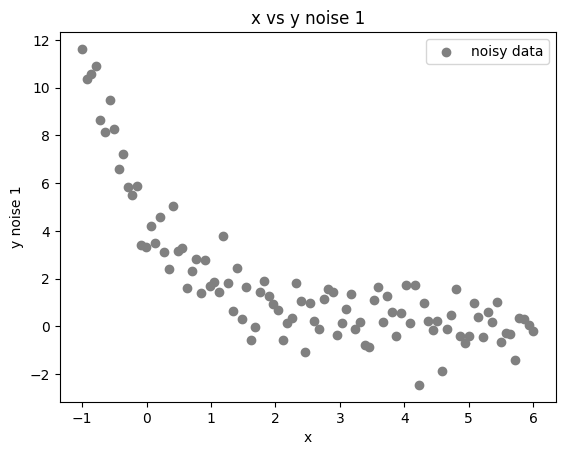

In [12]:
#2.1.5
plt.scatter(noisy_data['x'], noisy_data['y_noise_1'], c='gray', label='noisy data')
plt.xlabel('x')
plt.ylabel('y noise 1')
plt.title('x vs y noise 1')
plt.legend()
plt.show()

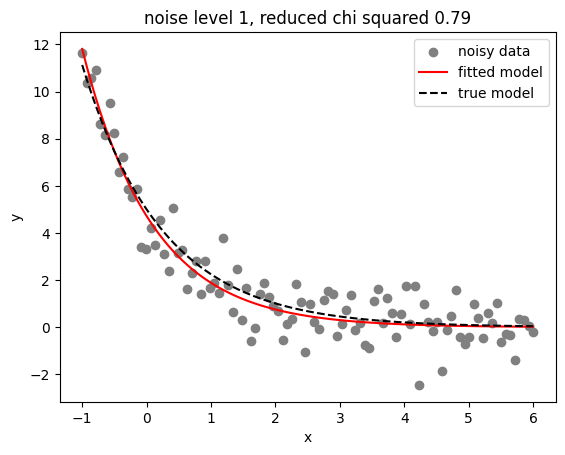

In [14]:
#2.2.1
def model(x, A, k):
    return A * np.exp(-k * x)

#2.2.2
x = noisy_data['x']
y_noise_1 = noisy_data['y_noise_1']
p0 = [1, 1]
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)

#2.2.3
A_fit, k_fit = popt

#2.2.4
f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)"

#2.2.5
residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

#2.2.6
residuals = noisy_data['y_noise_1'] - model(noisy_data['x'], A_fit, k_fit)
chi_squared_reduced = np.sum(residuals**2) / (len(noisy_data) - 2)

plt.scatter(noisy_data['x'], noisy_data['y_noise_1'], c='gray', label='noisy data')
plt.plot(noisy_data['x'], model(noisy_data['x'], A_fit, k_fit), c='red', label='fitted model')
plt.plot(noisy_data['x'], model(noisy_data['x'], 5, 0.8), c='black', linestyle='--', label='true model')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'noise level 1, reduced chi squared {chi_squared_reduced:.2f}')

plt.legend()
plt.show()

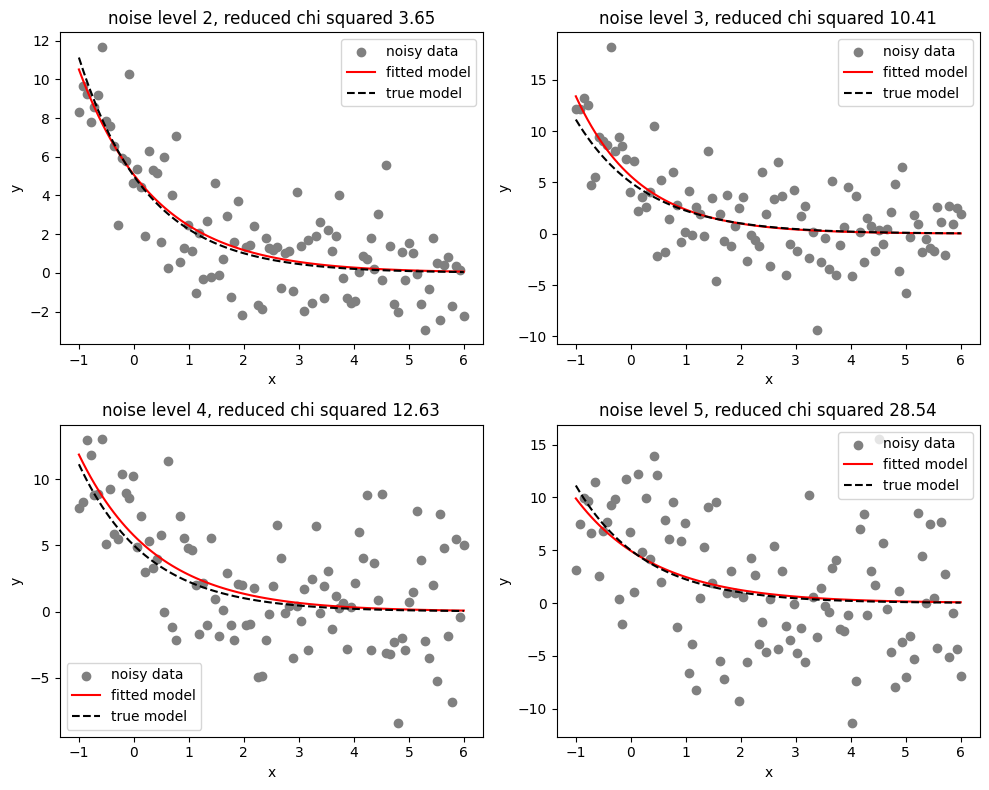

In [15]:
#2.3.1
def fit_model(x, y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    residuals = y - model(x, A_fit, k_fit)
    chi_squared_reduced = np.sum(residuals**2) / (len(x) - 2)
    return A_fit, k_fit, chi_squared_reduced

#2.3.2
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

#2.3.3
noise_cols = ['y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5']
for i, col in enumerate(noise_cols):
    ax = axes[i//2, i%2]
    A_fit, k_fit, chi2_red = fit_model(x, noisy_data[col])
    
    ax.scatter(x, noisy_data[col], c='gray', label='noisy data')
    ax.plot(x, model(x, A_fit, k_fit), c='red', label='fitted model')
    ax.plot(x, model(x, 5, 0.8), c='black', linestyle='--', label='true model')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'noise level {i+2}, reduced chi squared {chi2_red:.2f}')
    
    ax.legend()

plt.tight_layout()
plt.show()

#2.3.4
"""
What happens to the red and black dotted lines as you increase the noise level?
Why?
the red and black lines begin to flatten as the noise level increases, this is because there is more error so it's harder for the program to tell whether it's going up or down

What happens to the reduced chi-squared as you increase the noise level? Why?
the chi squared will increase, since it's a measure of aggregate error, which increases with noise
"""

In [17]:
#2.4.1
results = []
for i in range(1, 6):
    col = f'y_noise_{i}'
    A_fit, k_fit, chi2_red = fit_model(x, noisy_data[col])
    results.append({'noise_level': i,'A_fit': A_fit,'k_fit': k_fit,'reduced_chi_squared': chi2_red})

results_df = pd.DataFrame(results)
print(results_df)

#2.4.2
results_df.to_csv('noisy_parameters.csv', index=False)

   noise_level     A_fit     k_fit  reduced_chi_squared
0            1  4.714814  0.918308             0.790673
1            2  5.063889  0.730396             3.649382
2            3  5.609396  0.870372            10.410207
3            4  5.738727  0.725965            12.626832
4            5  4.943458  0.695012            28.538124
